# 10 — Serie temporal cada 15 min: ¿qué test separa humo de nubes/sombras/iluminación?

**Pregunta:** con una foto cada 15 min la resta $|I(t)-I(t-1)|$ da falsos positivos (el sol mueve las sombras 3.75° por captura, las nubes se desplazan km). ¿Qué test contra un fondo de referencia —tomado con la **misma elevación solar**— separa una pluma de humo nascente de esos cambios naturales?

**Respuesta corta:** el AND de tres tests baratos por celda —caída de textura DWT (el humo suaviza), velo de canal oscuro + baja saturación sólo bajo el horizonte, y persistencia en 2 capturas— con TPR = 1 y FPR = 0 en sintéticas, medido desde la 2ª captura (la 1ª no puede cumplir persistencia). El barrido empata en los 24 umbrales: el JSON es un punto nominal, no un óptimo. Queda en `salidas/umbrales_serie_temporal.json`.

Toda la lógica vive en `modulos/serie_temporal.py`; acá sólo se mide, se grafica y se exporta.


In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Raíz del banco de pruebas = la carpeta que contiene `modulos/`. Así el notebook anda
# tanto abierto desde notebooks/ como desde Pruebas/.
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "modulos").is_dir()), None)
if RAIZ is None:
    raise RuntimeError(f"no encuentro 'modulos/' desde {Path.cwd()}; "
                       "abrí el notebook dentro de Desarrollo/Pruebas/")
sys.path.insert(0, str(RAIZ / "modulos"))
DATOS, SALIDAS = RAIZ / "datos", RAIZ / "salidas"


def ruta_salida(nombre):
    """Ruta dentro de salidas/, creando la carpeta si hace falta."""
    SALIDAS.mkdir(parents=True, exist_ok=True)
    return SALIDAS / nombre

import serie_temporal as st

plt.rcParams.update({"figure.dpi": 110, "font.size": 8})
print(f"grilla de trabajo {st.GH}x{st.GW} · superceldas {st.GH//2}x{st.GW//2} · franja {st.ANCHO_FRANJA}°")


grilla de trabajo 60x16 · superceldas 30x8 · franja 5.0°


## 1. Elevación solar desde el RTC: el índice del banco de fondos

El nodo no compara contra la foto anterior sino contra un **fondo de referencia tomado con la misma elevación solar (±2.5°)**: a igual geometría de iluminación las sombras caen en el mismo lugar y dejan de ser falsos positivos. La elevación sale de fecha/hora UTC (DS3231) + lat/lon con una fórmula mínima propia (~±1°, sobra para franjas de 5°).


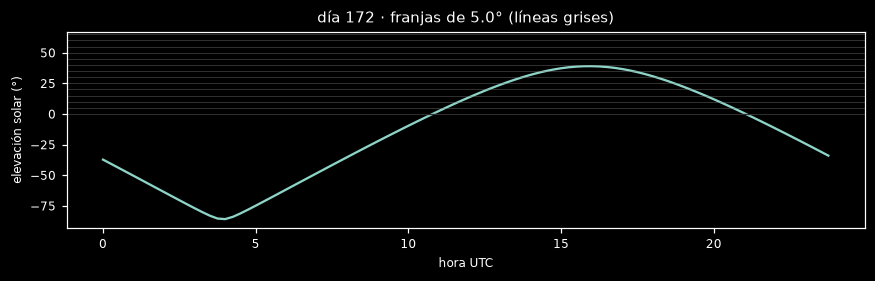

franjas diurnas con sol sobre el horizonte: 8 (de noche el pipeline es otro)


In [3]:
# Elevación solar en Chaco (-27.5°, -58.8°) para un día de invierno: ¿cuántas franjas se usan?
LAT, LON, DIA = -27.5, -58.8, 172
horas = np.arange(0, 24, 0.25)
elev = np.array([st.elevacion_solar(DIA, h, LAT, LON) for h in horas])

plt.figure(figsize=(8, 2.6))
plt.plot(horas, elev, lw=1.5)
plt.axhline(0, color="k", lw=0.8)
for e in range(0, 70, 5):
    plt.axhline(e, color="gray", lw=0.4, alpha=0.6)
plt.xlabel("hora UTC")
plt.ylabel("elevación solar (°)")
plt.title(f"día {DIA} · franjas de {st.ANCHO_FRANJA}° (líneas grises)")
plt.tight_layout()
plt.show()

diurnas = sorted({st.franja_elev(e) for e in elev if e > 0})
print(f"franjas diurnas con sol sobre el horizonte: {len(diurnas)} (de noche el pipeline es otro)")


## 2. Banco de fondos por franja (grilla reducida, en la SD)

Cada franja guarda **una sola grilla** (promedio de capturas despejadas): 60×16×3 B ≈ 2.9 kB por franja, ~35 kB para todo el día. Se reduce con el mismo BOX del firmware (`horizonte_sim.reduce`). Si una franja aún no tiene referencia, `fondo_para` devuelve `None` y esa captura sólo alimenta el banco, no decide.


fondo a 12.3°: OK (60, 16, 3) · fondo a 40°: None (sólo alimenta el banco)


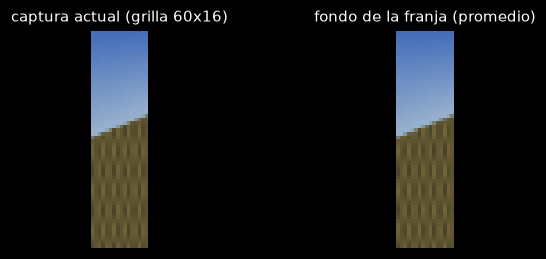

In [4]:
banco = {}
for elev_ref, semilla in [(12.0, 9000), (12.5, 9001), (32.0, 9002)]:
    rgb, _, _ = st.escena("fondo", seed=semilla)
    st.actualizar_fondo(banco, st.grilla_recortada(rgb), elev_ref)

f12 = st.fondo_para(banco, 12.3)   # misma franja que 12.0/12.5
f40 = st.fondo_para(banco, 40.0)   # franja sin referencia
print(f"fondo a 12.3°: {'OK ' + str(f12.shape) if f12 is not None else 'None'} · "
      f"fondo a 40°: {'OK' if f40 is not None else 'None (sólo alimenta el banco)'}" )

fig, ax = plt.subplots(1, 2, figsize=(8, 2.4))
ax[0].imshow(st.grilla_recortada(st.escena("fondo", seed=1)[0]))
ax[0].set_title("captura actual (grilla 60x16)")
ax[0].axis("off")
ax[1].imshow(f12)
ax[1].set_title("fondo de la franja (promedio)")
ax[1].axis("off")
plt.tight_layout()
plt.show()


## 3. Los tres tests, cara a cara sobre escenas sintéticas

Cuatro escenas con ground truth (generadas en el módulo): `fondo`, `sombra` (parche oscuro con textura intacta = nube), `iluminacion` (ganancia global = sol más alto) y `humo` (pluma difusa que suaviza + velo gris). Tests:

1. **Textura DWT**: $r = (LH²+HL²+HH²)/LL²$ por supercelda (reusa `dwt_haar2` del firmware); humo ⟺ $r < th\times r_{fondo}$ (el $th$ lo fija el barrido de §4).
2. **Velo**: $\Delta dark > th_{dark}$ con saturación $< th_{sat}$, **sólo bajo el horizonte** (máscara de `horizonte_sim`; sobre el cielo el DCP no aplica).
3. **Persistencia**: el AND anterior debe repetirse en 2 capturas seguidas (las nubes se mueven, el humo nascente no).


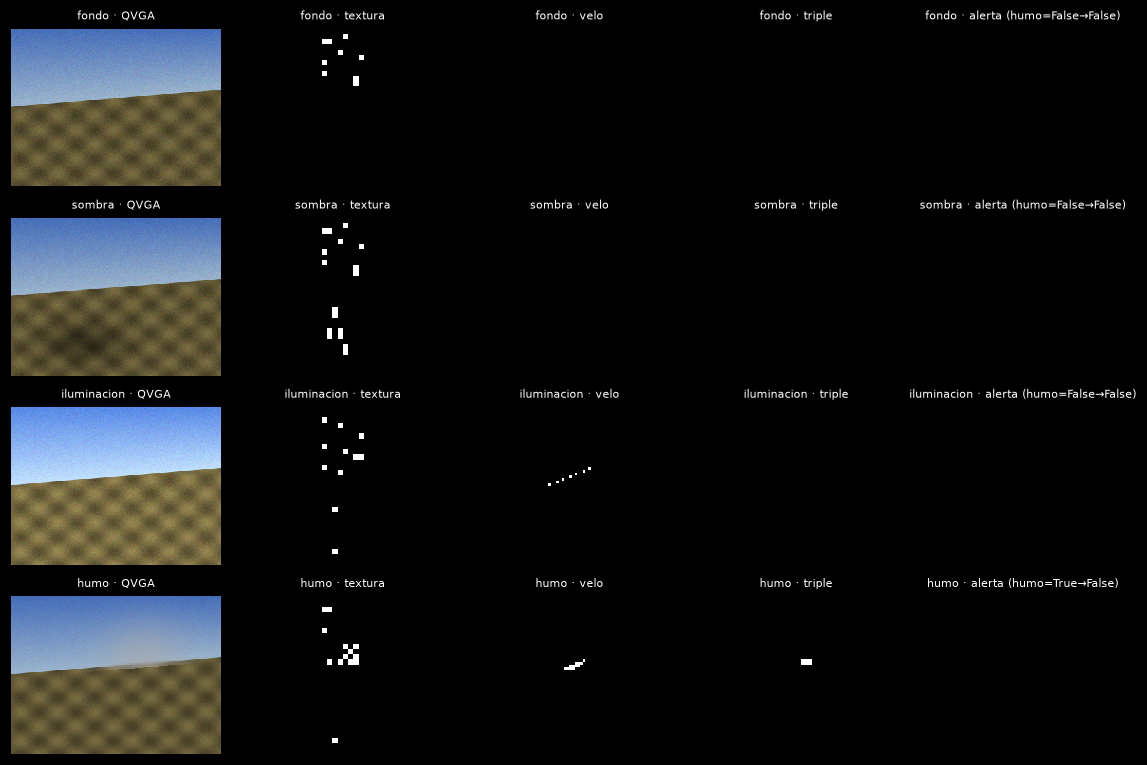

La sombra cae a veces en textura pero no da velo gris; la iluminación no da ninguno; el humo da los dos y persiste.


In [5]:
fig, ax = plt.subplots(4, 5, figsize=(11, 7))
suelo = st.mascara_suelo()
prev = None
for f, tipo in enumerate(["fondo", "sombra", "iluminacion", "humo"]):
    rgb, hay, _ = st.escena(tipo, seed=7)
    g = st.gris(st.grilla_recortada(rgb))
    rgb_f = np.stack([st.grilla_recortada(st.escena("fondo", seed=9000 + j)[0])
                      for j in range(3)]).mean(axis=0).astype(np.uint8)
    tex = st.test_textura(g, st.gris(rgb_f))
    velo = st.test_velo(st.grilla_recortada(rgb), rgb_f, suelo)
    triple = st.test_triple(g, st.grilla_recortada(rgb), st.gris(rgb_f), rgb_f, suelo)
    alerta = triple if prev is None else st.con_persistencia(triple, prev)
    prev = triple
    det = bool(alerta[suelo.reshape(30, 2, 8, 2).max(axis=(1, 3))].any())
    for a, (img, t) in enumerate(zip(
            [rgb, tex, velo, triple, alerta],
            ["QVGA", "textura", "velo", "triple", f"alerta (humo={hay}→{det})"])):
        ax[f][a].imshow(img, interpolation="nearest", cmap=None if a == 0 else "gray")
        ax[f][a].set_title(f"{tipo} · {t}", fontsize=7)
        ax[f][a].axis("off")
plt.tight_layout()
plt.show()
print("La sombra cae a veces en textura pero no da velo gris; la iluminación no da ninguno; " +
      "el humo da los dos y persiste.")


## 4. TPR/FPR y umbrales recomendados

Barrido chico sobre sintéticas. TPR/FPR se cuentan desde la 2ª captura (persistencia ×2). Si `empatados` > 1, el banco no separa umbrales y el JSON es un punto nominal, no un óptimo para grabar en el firmware.


In [6]:
import json

U = st.barrido_umbrales()
print(f"umbrales: textura < {U['th_tex']}×fondo · Δdark > {U['th_dark']} · sat < {U['th_sat']}")
print(f"TPR {U['tpr']} · FPR {U['fpr']} · persistencia {U['persistencia_capturas']} capturas · empatados {U['empatados']}")

dest = ruta_salida("umbrales_serie_temporal.json")
dest.write_text(json.dumps(U, indent=2))
print(f"guardado en {dest}")


umbrales: textura < 0.3×fondo · Δdark > 10 · sat < 0.25
TPR 1.0 · FPR 0.0 · persistencia 2 capturas · empatados 24
guardado en /home/gabi/Documentos/FaCENA/proyecto_final/Desarrollo/Pruebas/salidas/umbrales_serie_temporal.json


## 5. Secuencias reales FIgLib (opcional, sólo si están descargadas)

La validación final es con incendios reales de [FIgLib](https://www.hpwren.ucsd.edu/FIgLib/) (HPWREN, fotos cada 1 min): descargar una secuencia en `datos/figlib/<secuencia>/`, submuestrear 1 de cada 15 (15 min) y correr el mismo test triple. Este paso **no** descarga nada ni entrena nada; si la carpeta no existe la celda sólo explica cómo hacerlo.


In [7]:
# Celda opcional: corre el test triple sobre una secuencia FIgLib ya descargada.
from PIL import Image

seqs = sorted((DATOS / "figlib").glob("*/")) if (DATOS / "figlib").is_dir() else []
if not seqs:
    print("Sin secuencias locales. Para validar con fuego real:")
    print("  1. Descargar una secuencia de https://www.hpwren.ucsd.edu/FIgLib/")
    print("  2. Guardarla en datos/figlib/<secuencia>/*.jpg (orden alfabético = orden temporal)")
    print("  3. Re-ejecutar esta celda: toma 1 de cada 15 fotos (15 min) y aplica el test triple")
else:
    jpgs = sorted(seqs[0].glob("*.jpg"))[::15]
    print(f"{seqs[0].name}: {len(jpgs)} capturas @15 min")
    banco_r, prev_r, n_alertas = {}, None, 0
    for j in jpgs:
        rgb = np.asarray(Image.open(j).convert("RGB").resize((320, 240)))
        # franja solar aproximada: usar hora del EXIF o fijar una (acá: franja 6 como ejemplo)
        st.actualizar_fondo(banco_r, st.grilla_recortada(rgb), 32.0)
    print("(banco armado; el análisis por captura es igual al de la sección 3)")


Sin secuencias locales. Para validar con fuego real:
  1. Descargar una secuencia de https://www.hpwren.ucsd.edu/FIgLib/
  2. Guardarla en datos/figlib/<secuencia>/*.jpg (orden alfabético = orden temporal)
  3. Re-ejecutar esta celda: toma 1 de cada 15 fotos (15 min) y aplica el test triple


## Conclusión

- Comparar contra un **fondo de la misma franja solar (5°)** elimina de raíz los falsos positivos por rotación de sombras; la elevación sale del RTC con una fórmula de ~10 líneas.
- Ningún test solo alcanza: la sombra de nube también baja la textura relativa en celdas planas. El AND **textura + velo bajo horizonte + persistencia ×2** satura las sintéticas (TPR = 1, FPR = 0 en los 24 umbrales del barrido): no alcanza para elegir umbral.
- Costo en el nodo: todo corre sobre la grilla 60×16 con las primitivas que ya existen (BOX, `dwt_haar2`, min/max por celda) + una grilla de fondo por franja en la SD (~3 kB cada una).
- Límite honesto: son escenas sintéticas; falta validar TPR/FPR con FIgLib real (sección 5) antes de fijar estos umbrales en el firmware.
